# Visualization & Model Evaluation Report

Comprehensive evaluation of Random Forest, XGBoost, and LightGBM on **occupancy** (primary) and **volume** (secondary) targets. This notebook serves as the **model evaluation report** deliverable.

## Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import os
import glob
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white'
})

print("Libraries loaded!")

Libraries loaded!


## Load Results

Load predictions, metrics, and feature importance files.

### Load Predictions

In [2]:
# Predictions (with time + zone_id)
pred_df = pd.read_csv("../results/predictions/test_predictions.csv")
pred_df['time'] = pd.to_datetime(pred_df['time'])
print(f"Predictions: {pred_df.shape}")

Predictions: (184800, 10)


### Load Metrics

In [3]:
# Metrics
metrics_df = pd.read_csv("../results/metrics/model_metrics.csv")
print(f"Metrics: {metrics_df.shape}")
print(metrics_df.to_string(index=False))

Metrics: (6, 7)
   target        model       MAE       RMSE       R²  MAPE (%)  train_time_s
occupancy RandomForest  0.007457   0.190994 0.999915  0.020309    235.478110
occupancy      XGBoost  0.157386   0.899407 0.998120  0.621107      8.615578
occupancy     LightGBM  0.055315   0.141735 0.999953  0.367896      9.727306
   volume RandomForest 46.309226 181.381732 0.954743 43.887091    292.217120
   volume      XGBoost 44.255036 169.637343 0.960414 45.871004      8.963988
   volume     LightGBM 43.844577 170.664440 0.959933 48.777070      8.079681


### Load Feature Importance (All Models)

In [4]:
# Feature importance — load ALL models (occupancy + volume)
fi_dir = "../results/feature_importance"
fi_data_occ = {}
fi_data_vol = {}

name_map = {
    'randomforest': 'RandomForest',
    'xgboost': 'XGBoost',
    'lightgbm': 'LightGBM'
}

for fname in sorted(os.listdir(fi_dir)):
    if not fname.endswith('.csv'):
        continue
    if 'occupancy' in fname:
        key = fname.split('_occupancy')[0]
        model_name = name_map.get(key, key)
        fi_data_occ[model_name] = pd.read_csv(os.path.join(fi_dir, fname))
        print(f"  Loaded: {fname} → {model_name} (occupancy)")
    elif 'volume' in fname:
        key = fname.split('_volume')[0]
        model_name = name_map.get(key, key)
        fi_data_vol[model_name] = pd.read_csv(os.path.join(fi_dir, fname))
        print(f"  Loaded: {fname} → {model_name} (volume)")

# Keep backward-compatible alias
fi_data = fi_data_occ

print(f"\nOccupancy FI loaded for: {list(fi_data_occ.keys())}")
print(f"Volume FI loaded for:    {list(fi_data_vol.keys())}")

  Loaded: lightgbm_occupancy_feature_importance.csv → LightGBM (occupancy)
  Loaded: lightgbm_volume_feature_importance.csv → LightGBM (volume)
  Loaded: randomforest_occupancy_feature_importance.csv → RandomForest (occupancy)
  Loaded: randomforest_volume_feature_importance.csv → RandomForest (volume)
  Loaded: xgboost_occupancy_feature_importance.csv → XGBoost (occupancy)
  Loaded: xgboost_volume_feature_importance.csv → XGBoost (volume)

Occupancy FI loaded for: ['LightGBM', 'RandomForest', 'XGBoost']
Volume FI loaded for:    ['LightGBM', 'RandomForest', 'XGBoost']


## Chart 1 - Model Comparison Bar Chart (Occupancy)

Side-by-side comparison of all 4 metrics across the 3 models for the **primary target** (occupancy).

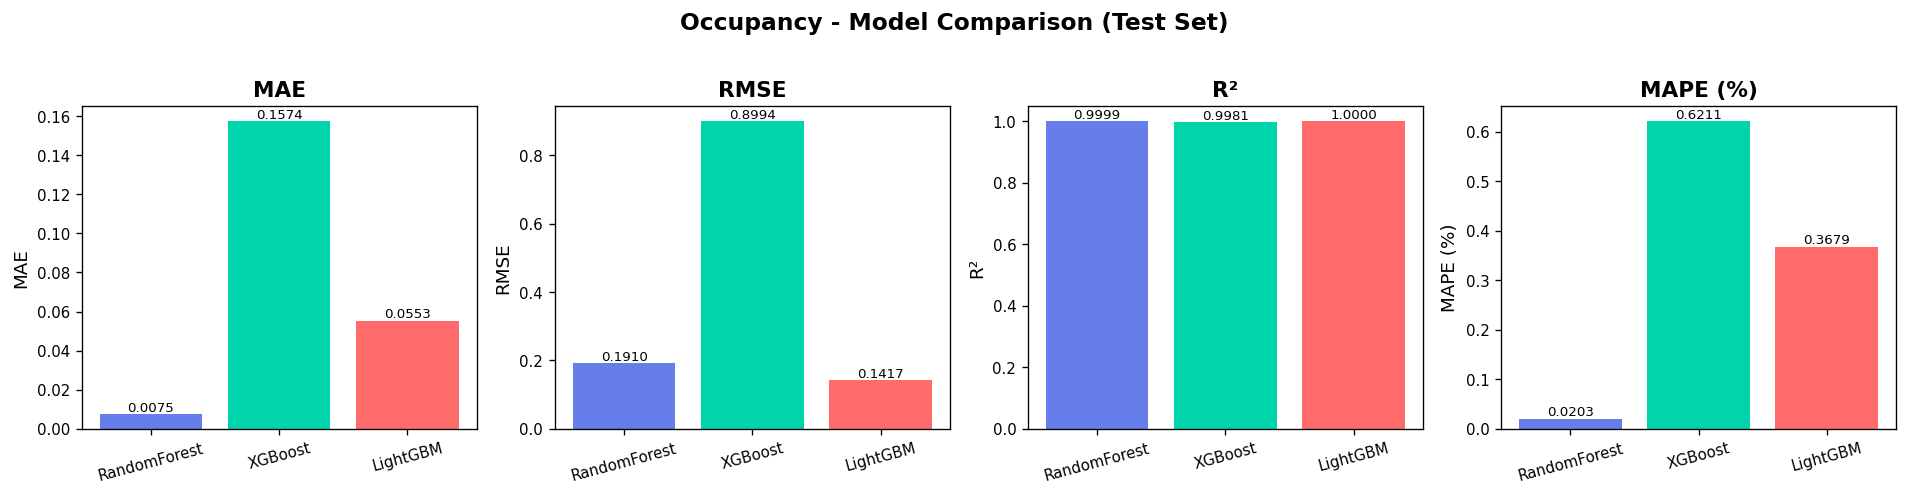

In [5]:
occ_metrics = metrics_df[metrics_df['target'] == 'occupancy'].copy()
occ_metrics = occ_metrics.set_index('model')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metric_cols = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
colors = ["#667eea", "#00d4aa", "#ff6b6b"]

for i, metric in enumerate(metric_cols):
    bars = axes[i].bar(occ_metrics.index, occ_metrics[metric], color=colors)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylabel(metric)
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2., height,
                     f'{height:.4f}', ha='center', va='bottom', fontsize=8)
    axes[i].tick_params(axis='x', rotation=15)

fig.suptitle("Occupancy - Model Comparison (Test Set)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/charts/chart_01_model_comparison_occupancy.png", bbox_inches='tight')
plt.show()

## Chart 2 - Model Comparison Bar Chart (Volume)

Side-by-side comparison of all 4 metrics across the 3 models for the **volume** (kWh).

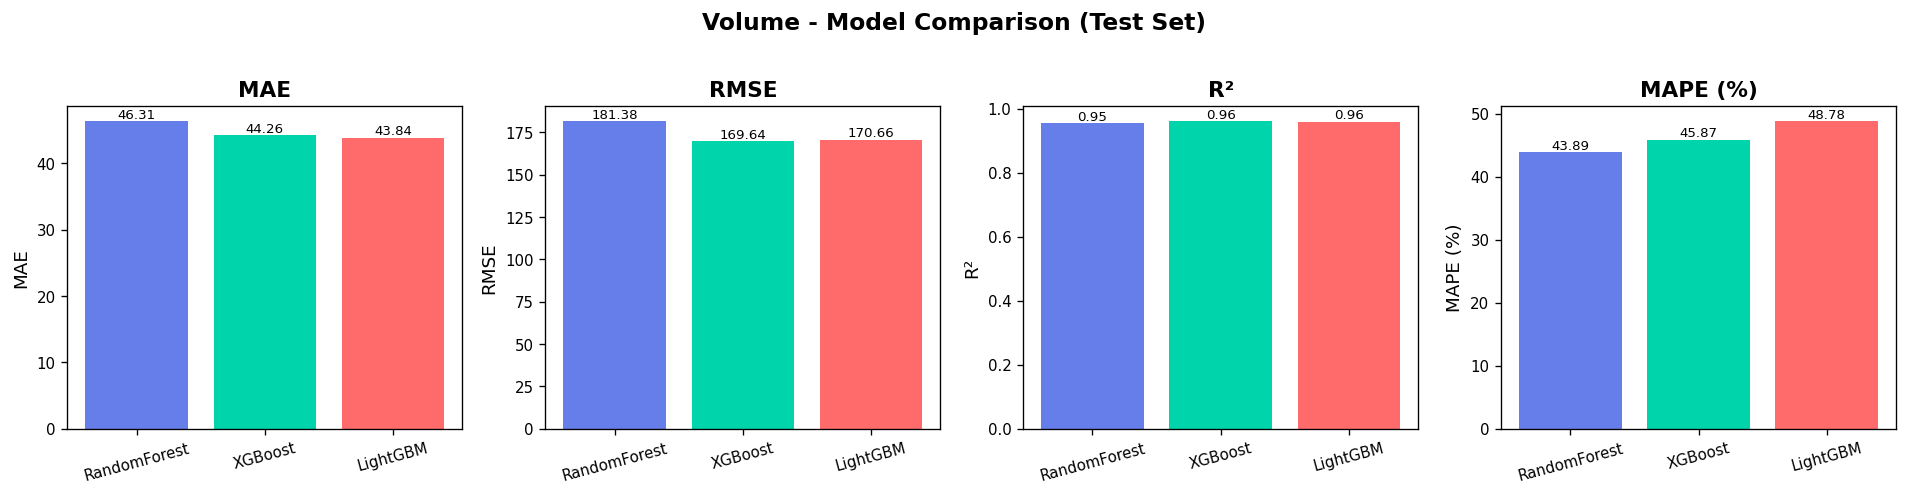

In [6]:
vol_metrics = metrics_df[metrics_df['target'] == 'volume'].copy()
vol_metrics = vol_metrics.set_index('model')

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metric_cols = ['MAE', 'RMSE', 'R²', 'MAPE (%)']

for i, metric in enumerate(metric_cols):
    bars = axes[i].bar(vol_metrics.index, vol_metrics[metric], color=colors)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylabel(metric)
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width() / 2., height,
                     f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    axes[i].tick_params(axis='x', rotation=15)

fig.suptitle("Volume - Model Comparison (Test Set)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/charts/chart_02_model_comparison_volume.png", bbox_inches='tight')
plt.show()

## Chart 3 - Combined Metrics Heatmap (Occupancy + Volume)

Heatmap showing all metrics for all models across both targets at a glance.

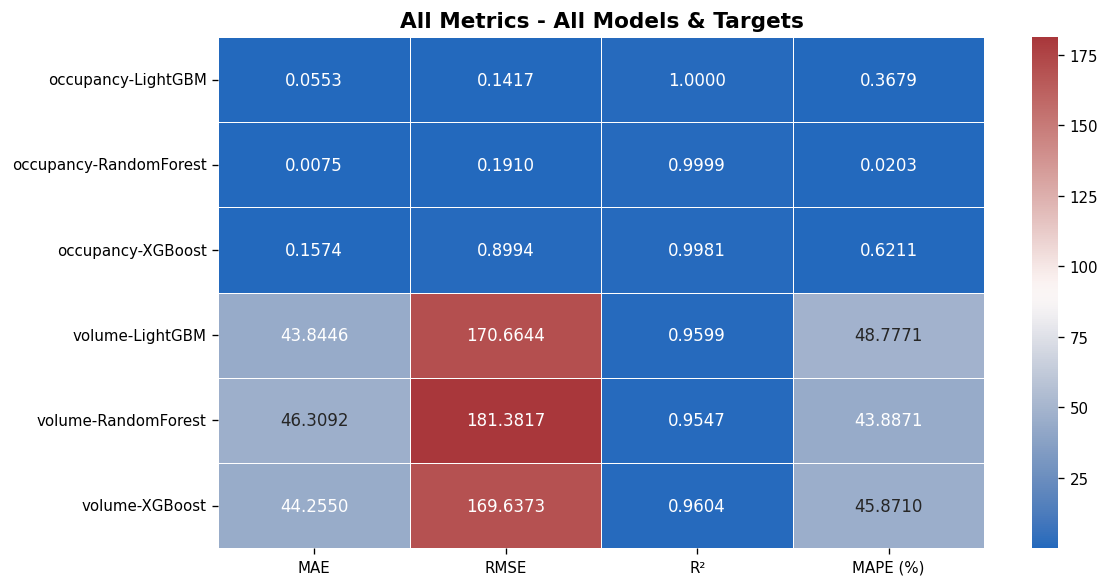

In [7]:
pivot = metrics_df.pivot_table(
    index=['target', 'model'],
    values=['MAE', 'RMSE', 'R²', 'MAPE (%)']
)[['MAE', 'RMSE', 'R²', 'MAPE (%)']]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='vlag', linewidths=0.5, ax=ax)
ax.set_title("All Metrics - All Models & Targets", fontweight='bold')
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../results/charts/chart_03_metrics_heatmap.png", bbox_inches='tight')
plt.show()

## Chart 4 - Actual vs Predicted Time Series (Occupancy, 1 Week)

Prediction quality for **occupancy** on the best occupancy model over a sample week.

Best occupancy model: LightGBM (RMSE = 0.1417)


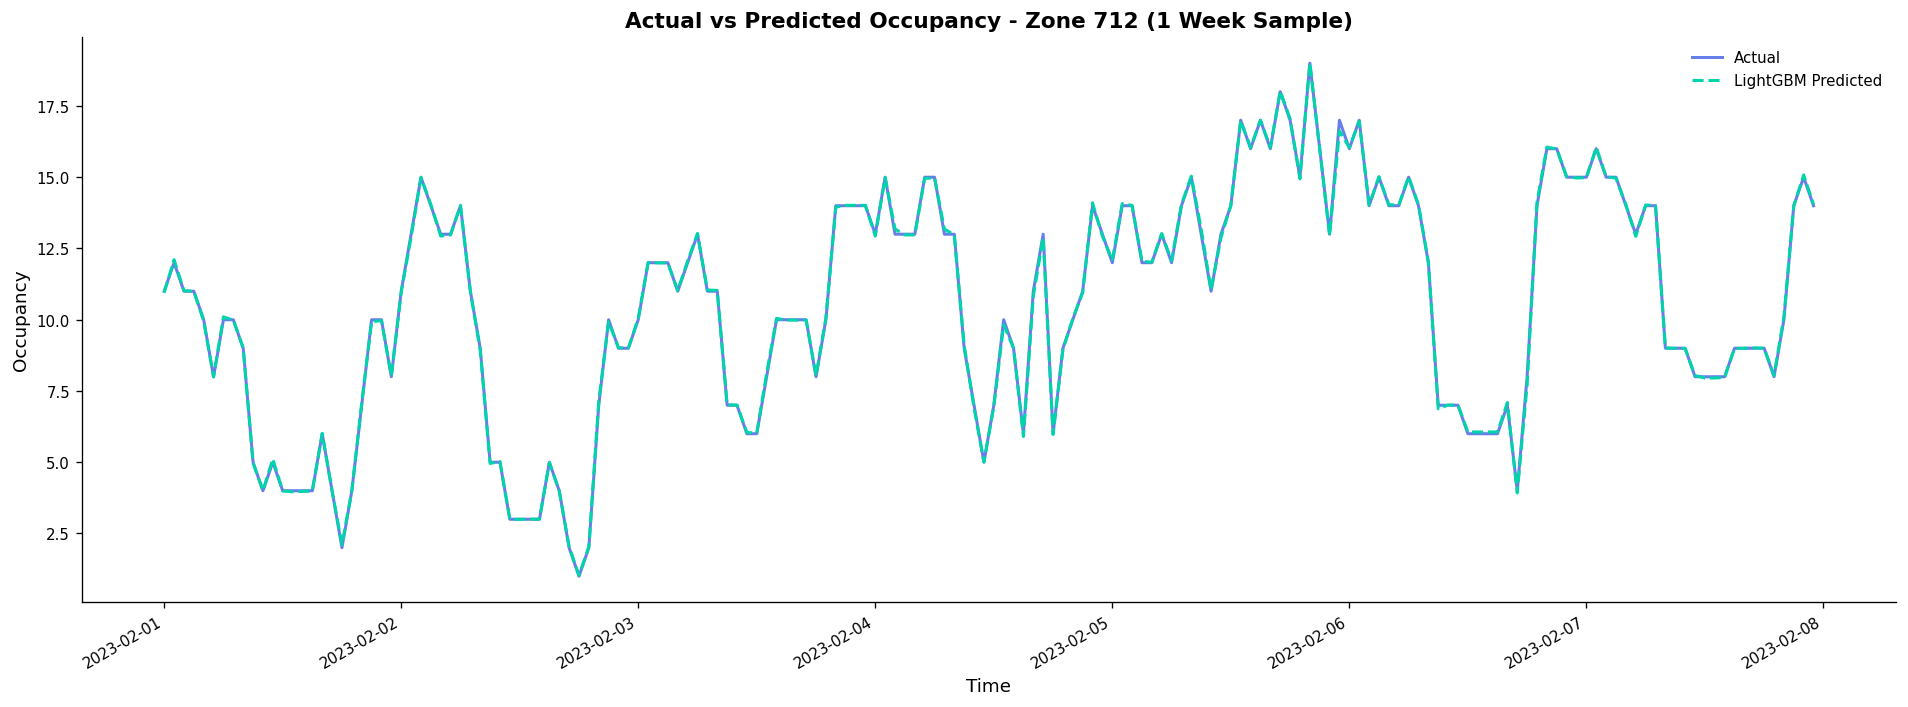

In [8]:
# Identify best model by lowest RMSE on occupancy
best_model_name = occ_metrics['RMSE'].idxmin()
pred_col = f"{best_model_name.lower()}_occ_pred"
print(f"Best occupancy model: {best_model_name} (RMSE = {occ_metrics.loc[best_model_name, 'RMSE']:.4f})")

# Same zone selection logic
zone_means = pred_df.groupby('zone_id')['actual_occupancy'].mean()
target_zone = zone_means.sub(zone_means.median()).abs().idxmin()

zone_df = pred_df[pred_df['zone_id'] == target_zone].sort_values('time')
sample = zone_df.head(168)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    sample['time'],
    sample['actual_occupancy'],
    label='Actual',
    color='#667eea',
    linewidth=1.8
)

ax.plot(
    sample['time'],
    sample[pred_col],
    label=f'{best_model_name} Predicted',
    color='#00d4aa',
    linewidth=1.8,
    linestyle='--'
)

ax.fill_between(
    sample['time'],
    sample['actual_occupancy'],
    sample[pred_col],
    color='#00d4aa',
    alpha=0.08
)

ax.set_title(
    f"Actual vs Predicted Occupancy - Zone {target_zone} (1 Week Sample)",
    fontweight='bold'
)

ax.set_xlabel("Time")
ax.set_ylabel("Occupancy")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("../results/charts/chart_04_actual_vs_predicted_timeseries.png", bbox_inches='tight')
plt.show()

## Chart 5 - Actual vs Predicted Time Series (Volume, 1 Week)

Prediction quality for **volume (kWh)** on the best volume model over a sample week.

Best volume model: XGBoost (RMSE = 169.64)


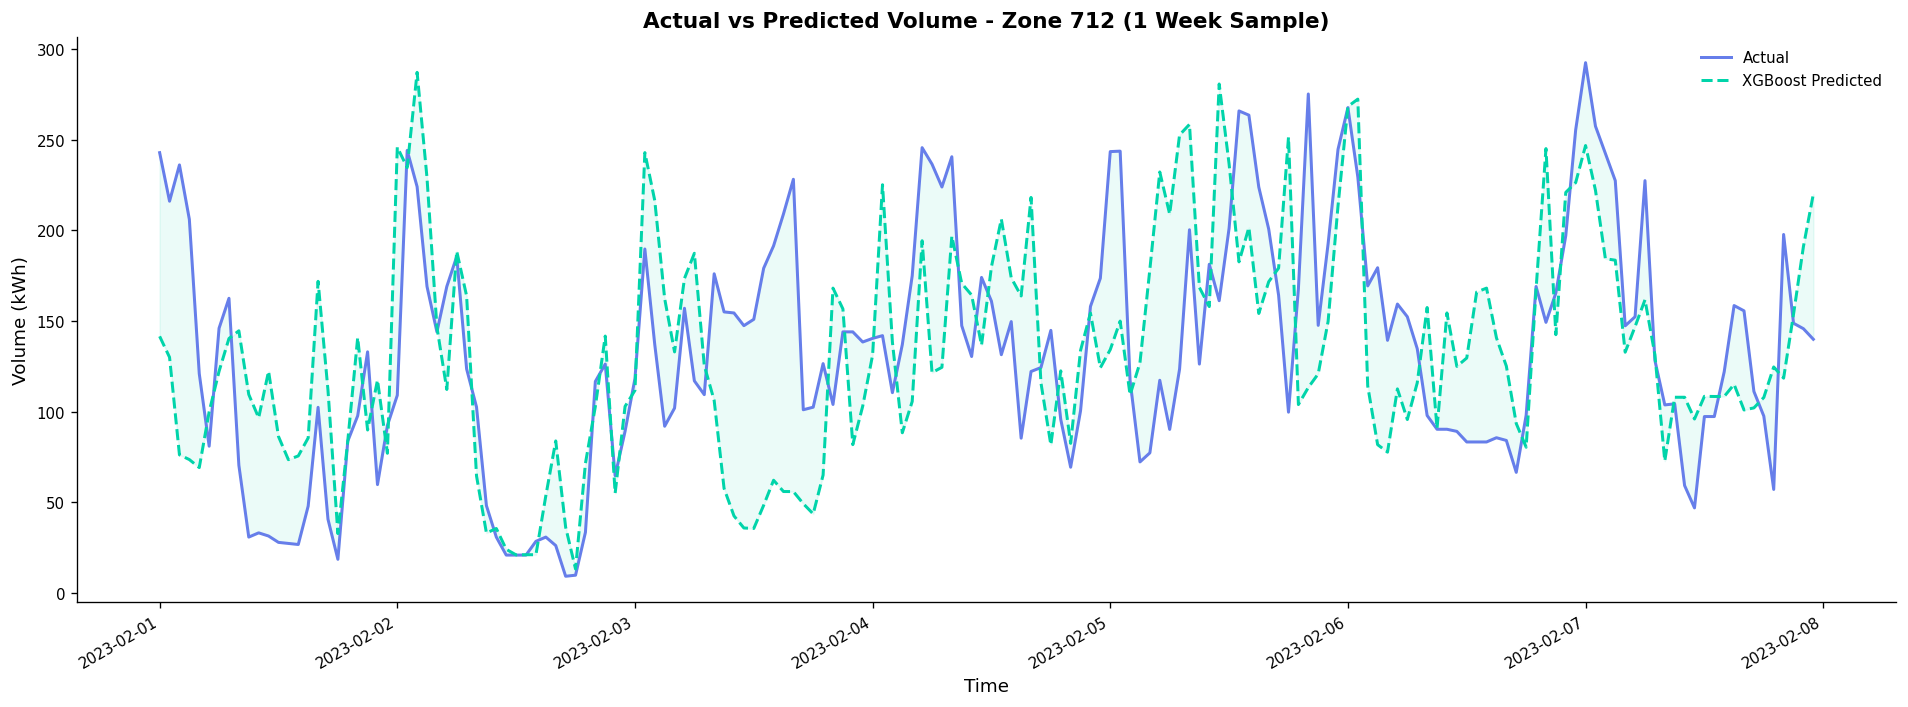

In [9]:
# Best volume model
best_vol_model = vol_metrics['RMSE'].idxmin()
vol_pred_col = f"{best_vol_model.lower()}_vol_pred"
print(f"Best volume model: {best_vol_model} (RMSE = {vol_metrics.loc[best_vol_model, 'RMSE']:.2f})")

# Same zone as occupancy chart for consistency
zone_df = pred_df[pred_df['zone_id'] == target_zone].sort_values('time')
sample = zone_df.head(168)

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    sample['time'],
    sample['actual_volume'],
    label='Actual',
    color='#667eea',
    linewidth=1.8
)

ax.plot(
    sample['time'],
    sample[vol_pred_col],
    label=f'{best_vol_model} Predicted',
    color='#00d4aa',
    linewidth=1.8,
    linestyle='--'
)

ax.fill_between(
    sample['time'],
    sample['actual_volume'],
    sample[vol_pred_col],
    color='#00d4aa',
    alpha=0.08
)

ax.set_title(
    f"Actual vs Predicted Volume - Zone {target_zone} (1 Week Sample)",
    fontweight='bold'
)

ax.set_xlabel("Time")
ax.set_ylabel("Volume (kWh)")
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("../results/charts/chart_05_actual_vs_predicted_volume.png", bbox_inches='tight')
plt.show()

## Chart 6 - Predicted vs Actual Scatter Plot (Occupancy)

Identity line comparison - points closer to the diagonal = better predictions.

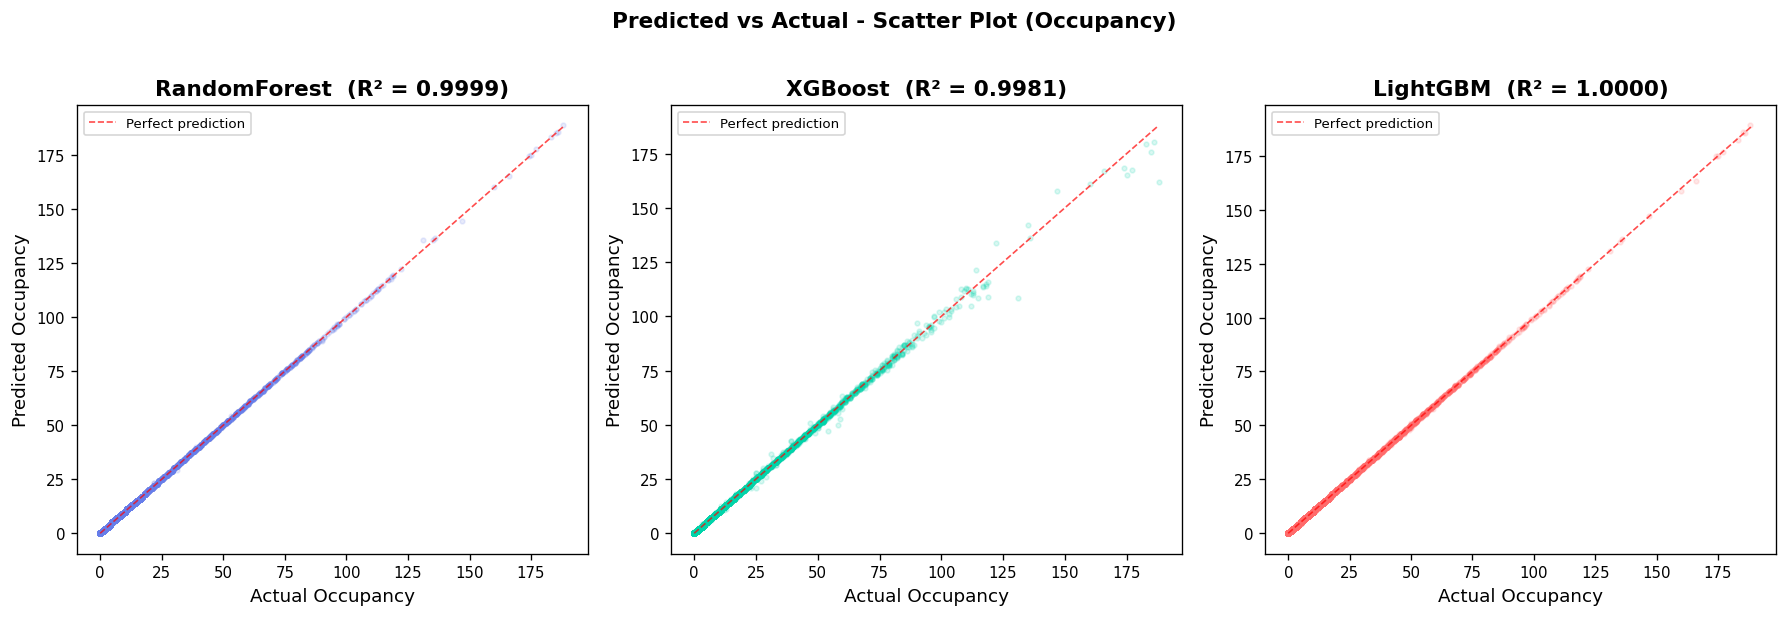

In [10]:
model_pred_cols = {
    'RandomForest': 'randomforest_occ_pred',
    'XGBoost': 'xgboost_occ_pred',
    'LightGBM': 'lightgbm_occ_pred'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, col) in zip(axes, model_pred_cols.items()):
    sample = pred_df.sample(n=min(5000, len(pred_df)), random_state=42)
    ax.scatter(sample['actual_occupancy'], sample[col], alpha=0.15, s=8, color=colors[list(model_pred_cols.keys()).index(name)])
    # Identity line
    lims = [min(sample['actual_occupancy'].min(), sample[col].min()),
            max(sample['actual_occupancy'].max(), sample[col].max())]
    ax.plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='Perfect prediction')
    r2 = occ_metrics.loc[name, 'R²']
    ax.set_title(f"{name}  (R² = {r2:.4f})", fontweight='bold')
    ax.set_xlabel("Actual Occupancy")
    ax.set_ylabel("Predicted Occupancy")
    ax.legend(fontsize=8)

fig.suptitle("Predicted vs Actual - Scatter Plot (Occupancy)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/charts/chart_06_scatter_plot_occupancy.png", bbox_inches='tight')
plt.show()

## Chart 7 - Predicted vs Actual Scatter Plot (Volume)

Identity line comparison - points closer to the diagonal = better predictions.

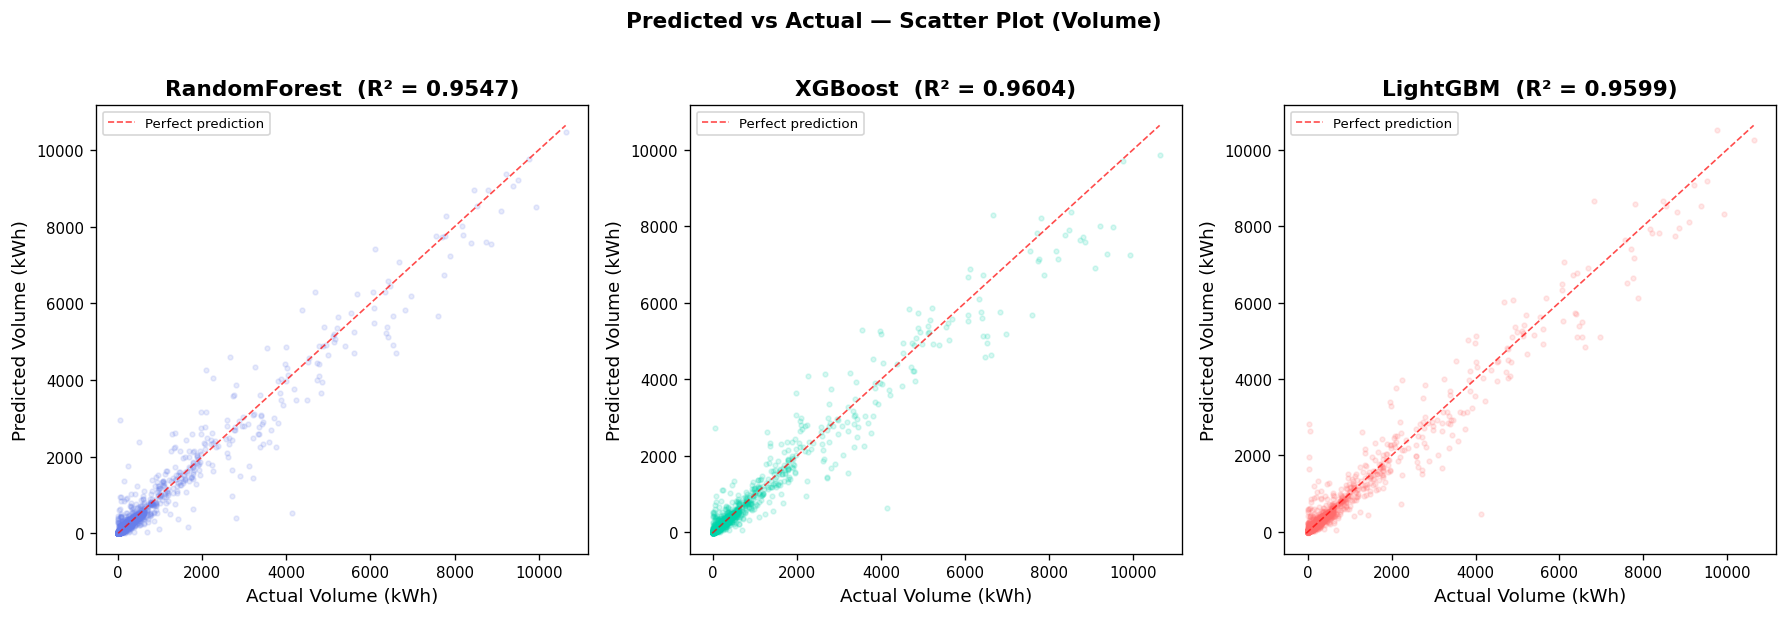

In [11]:
vol_pred_cols = {
    'RandomForest': 'randomforest_vol_pred',
    'XGBoost': 'xgboost_vol_pred',
    'LightGBM': 'lightgbm_vol_pred'
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, col) in zip(axes, vol_pred_cols.items()):
    sample = pred_df.sample(n=min(5000, len(pred_df)), random_state=42)
    ax.scatter(sample['actual_volume'], sample[col], alpha=0.15, s=8,
               color=colors[list(vol_pred_cols.keys()).index(name)])
    lims = [min(sample['actual_volume'].min(), sample[col].min()),
            max(sample['actual_volume'].max(), sample[col].max())]
    ax.plot(lims, lims, 'r--', linewidth=1, alpha=0.7, label='Perfect prediction')
    r2 = vol_metrics.loc[name, 'R²']
    ax.set_title(f"{name}  (R² = {r2:.4f})", fontweight='bold')
    ax.set_xlabel("Actual Volume (kWh)")
    ax.set_ylabel("Predicted Volume (kWh)")
    ax.legend(fontsize=8)

fig.suptitle("Predicted vs Actual — Scatter Plot (Volume)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/charts/chart_07_scatter_plot_volume.png", bbox_inches='tight')
plt.show()

## Chart 8 - Residual Distribution (Occupancy)

Distribution of prediction errors (residual = actual - predicted). Ideally centered around 0 with low spread.

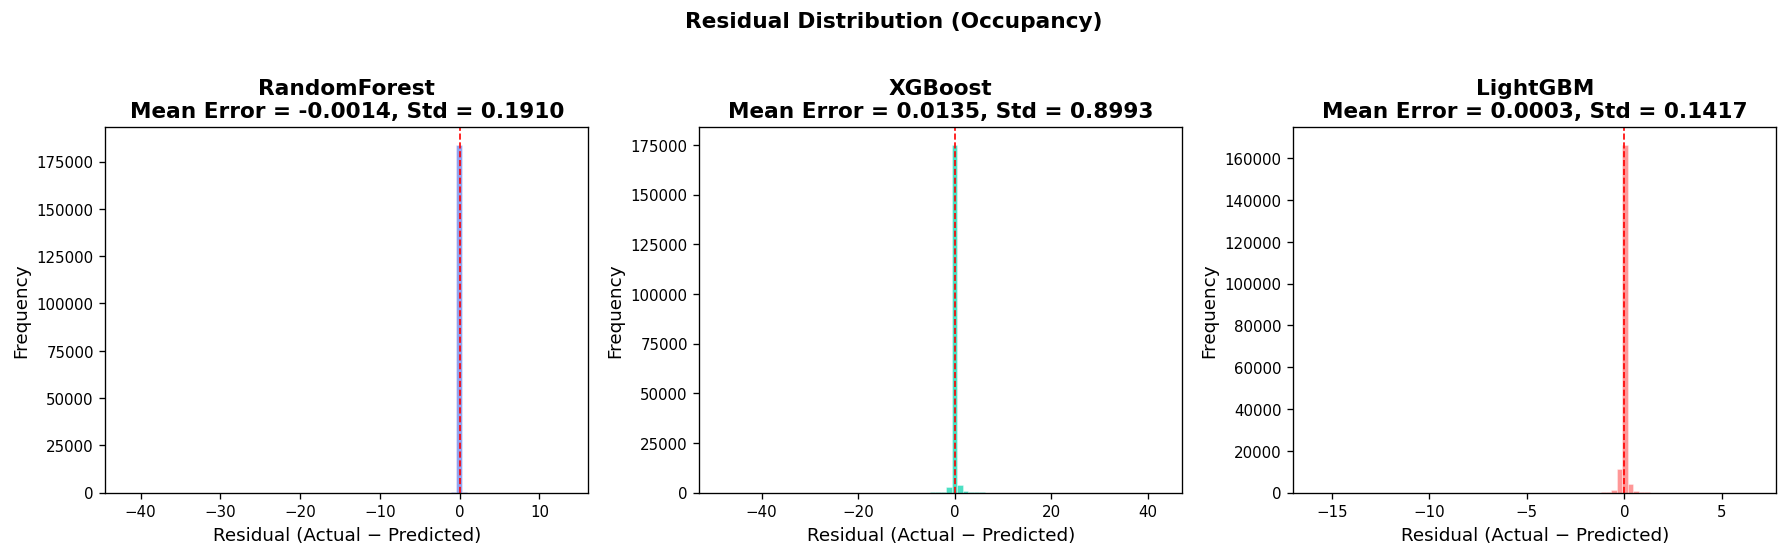

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, col) in zip(axes, model_pred_cols.items()):
    residuals = pred_df['actual_occupancy'] - pred_df[col]
    ax.hist(residuals, bins=80, color=colors[list(model_pred_cols.keys()).index(name)],
            alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{name}\nMean Error = {residuals.mean():.4f}, Std = {residuals.std():.4f}", fontweight='bold')
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Frequency")

fig.suptitle("Residual Distribution (Occupancy)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/charts/chart_08_residuals_occupancy.png", bbox_inches='tight')
plt.show()

## Chart 9 - Residual Distribution (Volume)

Distribution of prediction errors (residual = actual - predicted). Ideally centered around 0 with low spread.

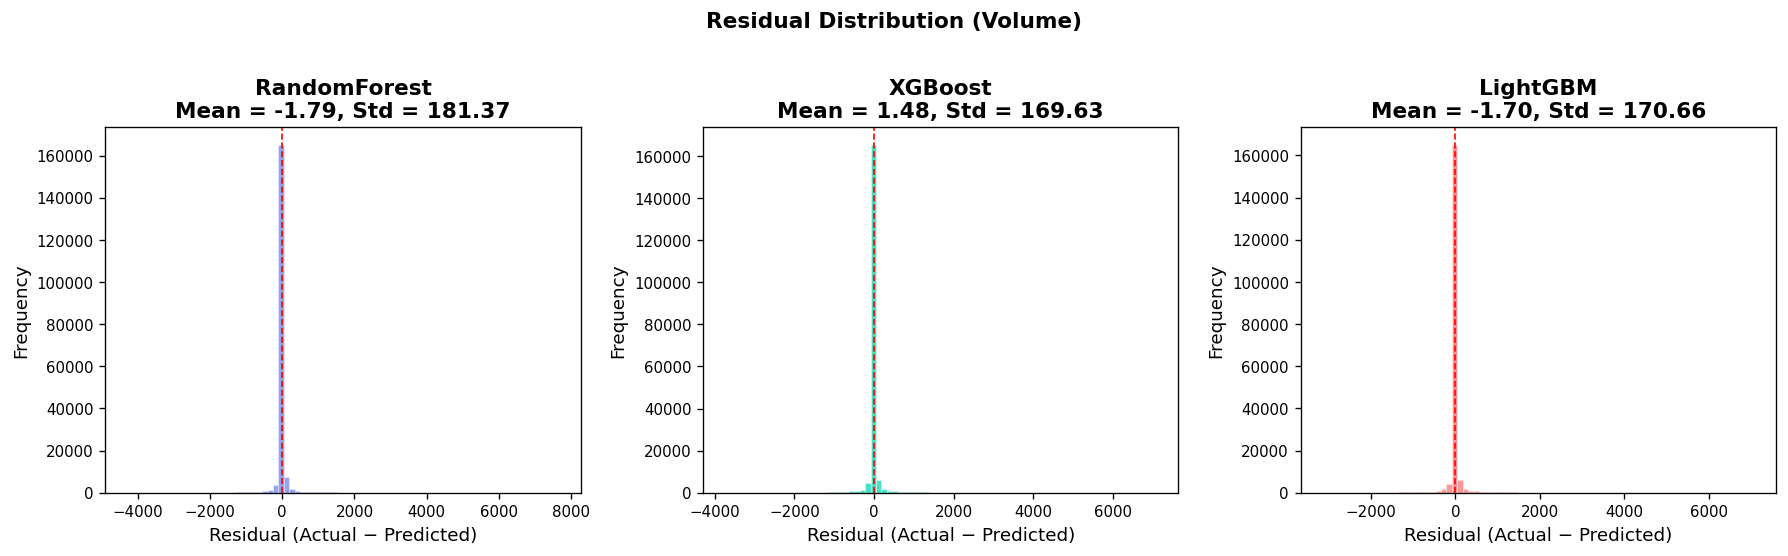

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, col) in zip(axes, vol_pred_cols.items()):
    residuals = pred_df['actual_volume'] - pred_df[col]
    ax.hist(residuals, bins=80, color=colors[list(vol_pred_cols.keys()).index(name)],
            alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f"{name}\nMean = {residuals.mean():.2f}, Std = {residuals.std():.2f}", fontweight='bold')
    ax.set_xlabel("Residual (Actual − Predicted)")
    ax.set_ylabel("Frequency")

fig.suptitle("Residual Distribution (Volume)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/charts/chart_09_residuals_volume.png", bbox_inches='tight')
plt.show()

## Chart 10 - Feature Importance (Best Model - Top 15, Occupancy)

Which features matter most for predicting **occupancy**?

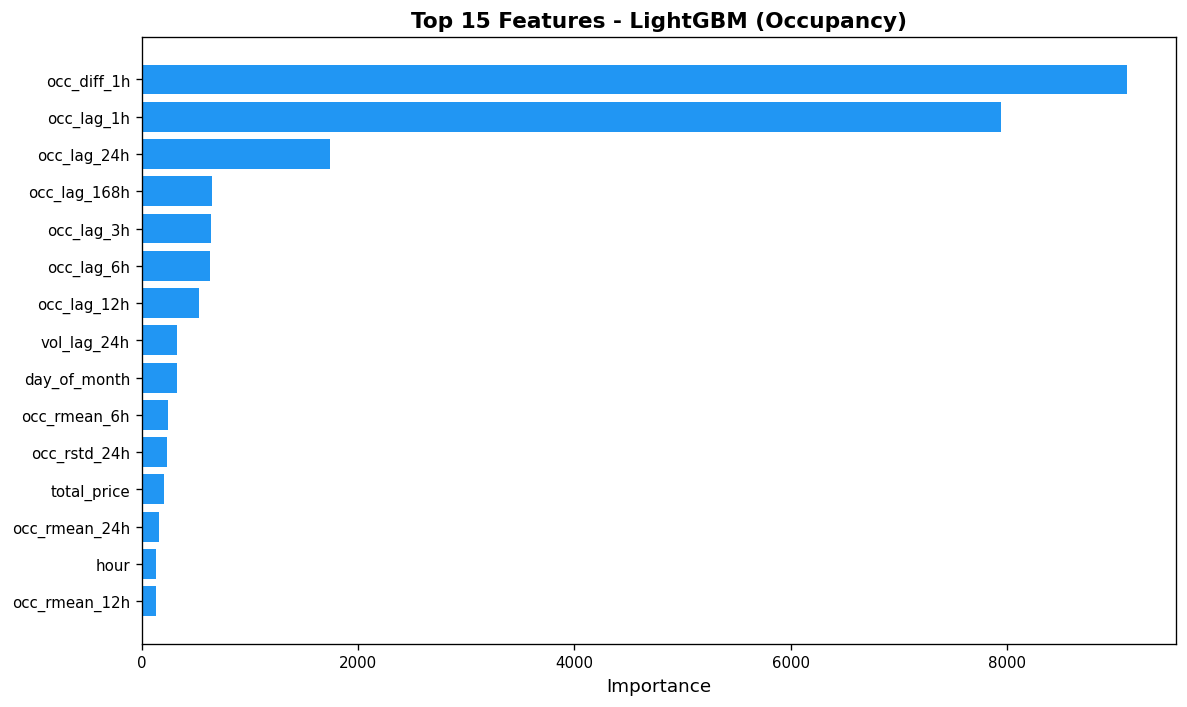

In [14]:
best_fi = fi_data[best_model_name].head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(best_fi['feature'][::-1], best_fi['importance'][::-1], color='#2196F3')
ax.set_xlabel("Importance")
ax.set_title(f"Top 15 Features - {best_model_name} (Occupancy)", fontweight='bold')
plt.tight_layout()
plt.savefig("../results/charts/chart_10_feature_importance_best_occupancy.png", bbox_inches='tight')
plt.show()

## Chart 11 - Feature Importance (Best Model - Top 15, Volume)

Which features matter most for predicting **volume (kWh)**?

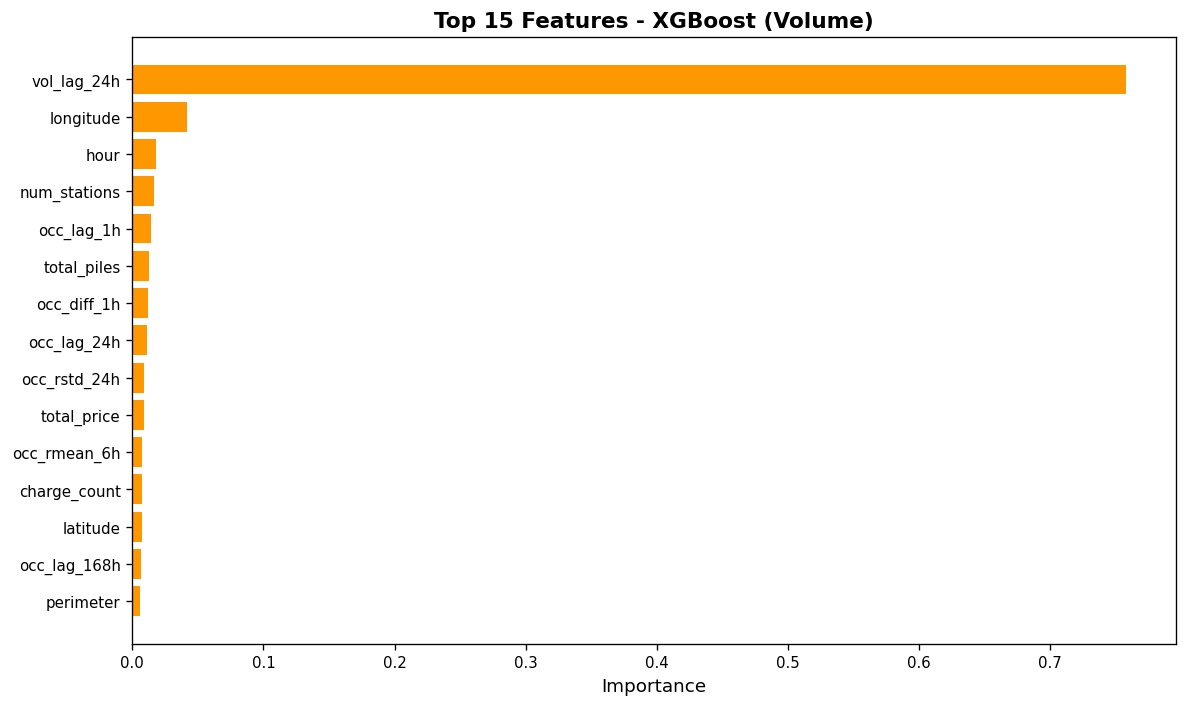

In [15]:
# Best volume model feature importance
best_vol_fi = fi_data_vol[best_vol_model].head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(best_vol_fi['feature'][::-1], best_vol_fi['importance'][::-1], color='#FF9800')
ax.set_xlabel("Importance")
ax.set_title(f"Top 15 Features - {best_vol_model} (Volume)", fontweight='bold')
plt.tight_layout()
plt.savefig("../results/charts/chart_11_feature_importance_best_volume.png", bbox_inches='tight')
plt.show()

## Chart 12 - Feature Importance Comparison (Top 10, Occupancy)

Compare which features each model relies on most for **occupancy**. Differences reveal model strategies.

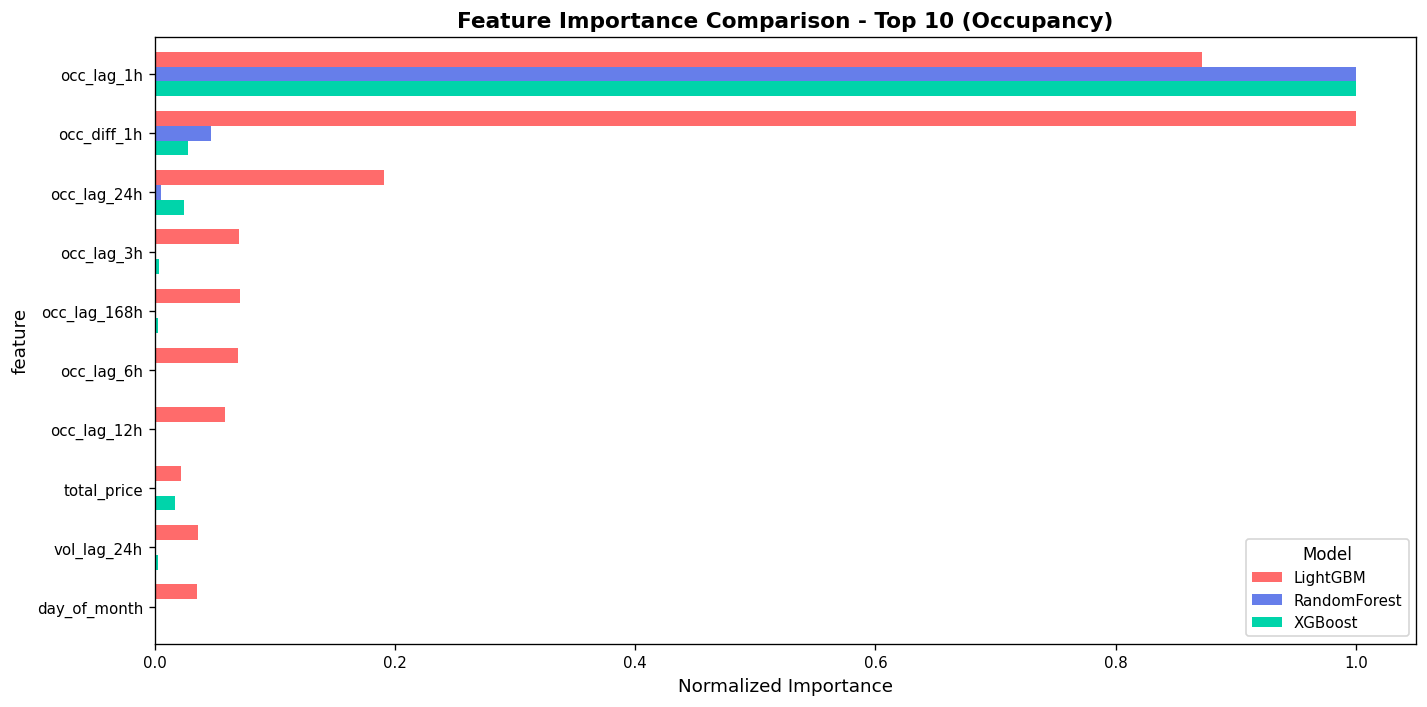

In [16]:
top_n = 10

# Get union of top 10 features across all models
all_top = set()
for name, fi in fi_data_occ.items():
    all_top.update(fi.head(top_n)['feature'].tolist())

# Build comparison DataFrame — normalize importance per model to [0, 1]
comp_rows = []
for name, fi in fi_data_occ.items():
    fi_dict = dict(zip(fi['feature'], fi['importance']))
    max_imp = max(fi_dict.values()) if fi_dict else 1
    for feat in all_top:
        comp_rows.append({
            'model': name,
            'feature': feat,
            'importance': fi_dict.get(feat, 0) / max_imp  # normalize
        })

comp_df = pd.DataFrame(comp_rows)

# Sort features by average importance
feat_order = comp_df.groupby('feature')['importance'].mean().sort_values(ascending=False).head(top_n).index.tolist()
comp_df = comp_df[comp_df['feature'].isin(feat_order)]

fig, ax = plt.subplots(figsize=(12, 6))
comp_pivot = comp_df.pivot(index='feature', columns='model', values='importance').loc[feat_order]

bar_colors = {'RandomForest': '#667eea', 'XGBoost': '#00d4aa', 'LightGBM': '#ff6b6b'}
plot_colors = [bar_colors[c] for c in comp_pivot.columns]

comp_pivot.plot(kind='barh', ax=ax, color=plot_colors, width=0.75)
ax.set_xlabel("Normalized Importance")
ax.set_title(f"Feature Importance Comparison - Top {top_n} (Occupancy)", fontweight='bold')
ax.invert_yaxis()
ax.legend(title='Model')
plt.tight_layout()
plt.savefig("../results/charts/chart_12_feature_importance_comparison_occupancy.png", bbox_inches='tight')
plt.show()

## Chart 13 - Feature Importance Comparison (Top 10, Volume)

Compare which features each model relies on most for **volume (kWh)**.

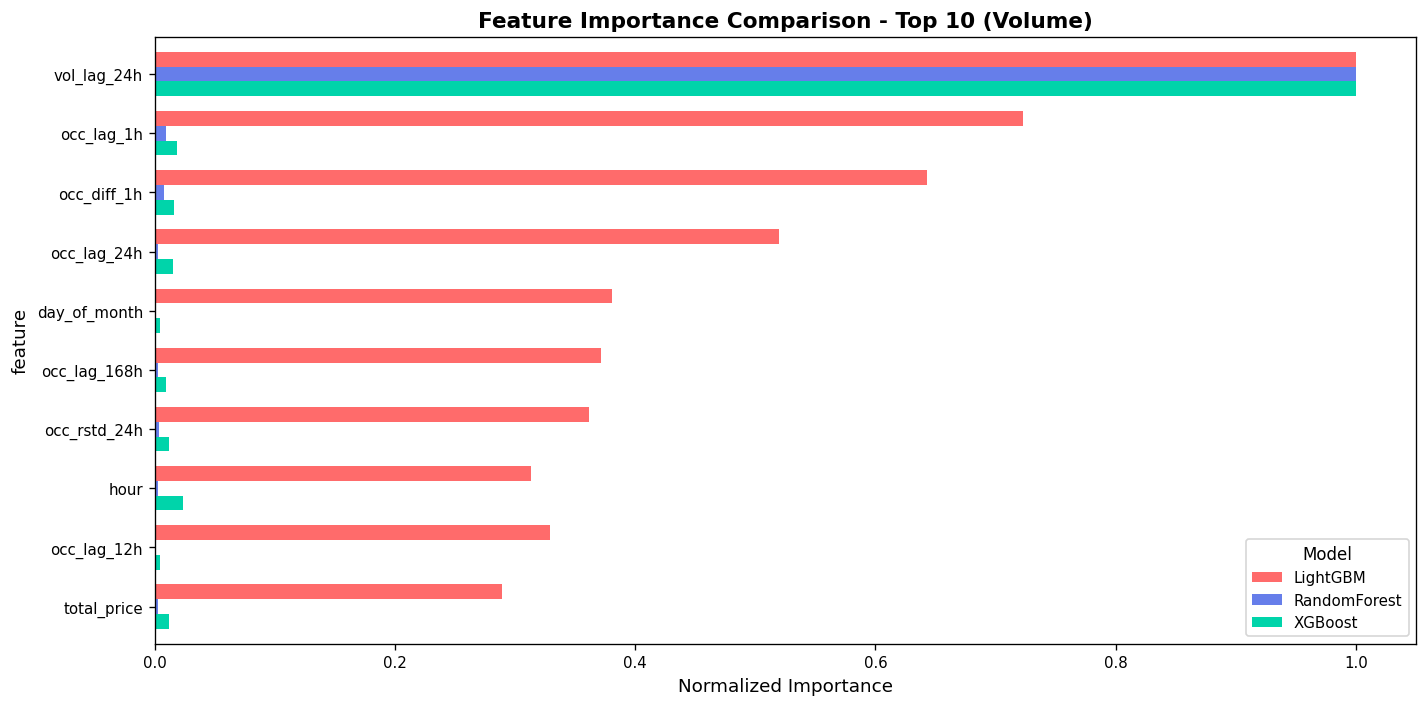

In [17]:
top_n = 10

# Get union of top 10 features across all volume models
all_top_vol = set()
for name, fi in fi_data_vol.items():
    all_top_vol.update(fi.head(top_n)['feature'].tolist())

# Build comparison DataFrame — normalize importance per model to [0, 1]
comp_rows_vol = []
for name, fi in fi_data_vol.items():
    fi_dict = dict(zip(fi['feature'], fi['importance']))
    max_imp = max(fi_dict.values()) if fi_dict else 1
    for feat in all_top_vol:
        comp_rows_vol.append({
            'model': name,
            'feature': feat,
            'importance': fi_dict.get(feat, 0) / max_imp
        })

comp_df_vol = pd.DataFrame(comp_rows_vol)

feat_order_vol = comp_df_vol.groupby('feature')['importance'].mean().sort_values(ascending=False).head(top_n).index.tolist()
comp_df_vol = comp_df_vol[comp_df_vol['feature'].isin(feat_order_vol)]

fig, ax = plt.subplots(figsize=(12, 6))
comp_pivot_vol = comp_df_vol.pivot(index='feature', columns='model', values='importance').loc[feat_order_vol]

bar_colors = {'RandomForest': '#667eea', 'XGBoost': '#00d4aa', 'LightGBM': '#ff6b6b'}
plot_colors = [bar_colors[c] for c in comp_pivot_vol.columns]

comp_pivot_vol.plot(kind='barh', ax=ax, color=plot_colors, width=0.75)
ax.set_xlabel("Normalized Importance")
ax.set_title(f"Feature Importance Comparison - Top {top_n} (Volume)", fontweight='bold')
ax.invert_yaxis()
ax.legend(title='Model')
plt.tight_layout()
plt.savefig("../results/charts/chart_13_feature_importance_comparison_volume.png", bbox_inches='tight')
plt.show()

## Chart 14 - Zone-Level RMSE (Best & Worst Predicted Zones, Occupancy)

Identify which zones the best model predicts well vs poorly for **occupancy**.

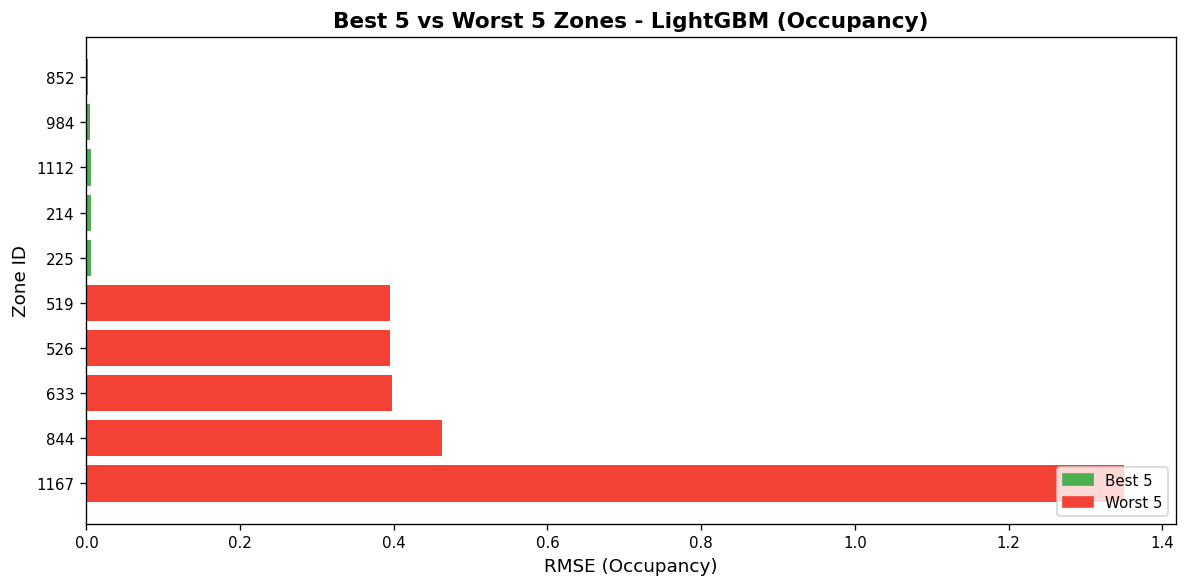

In [18]:
pred_col_best = f"{best_model_name.lower()}_occ_pred"

zone_rmse = pred_df.groupby('zone_id').apply(
    lambda g: np.sqrt(((g['actual_occupancy'] - g[pred_col_best]) ** 2).mean())
).reset_index(name='RMSE').sort_values('RMSE')

top5 = zone_rmse.head(5)
bottom5 = zone_rmse.tail(5)
plot_zones = pd.concat([top5, bottom5])

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#4CAF50'] * len(top5) + ['#F44336'] * len(bottom5)
ax.barh(plot_zones['zone_id'].astype(str), plot_zones['RMSE'], color=bar_colors)
ax.set_xlabel("RMSE (Occupancy)")
ax.set_ylabel("Zone ID")
ax.set_title(f"Best 5 vs Worst 5 Zones - {best_model_name} (Occupancy)", fontweight='bold')
ax.invert_yaxis()

ax.legend(handles=[Patch(color='#4CAF50', label='Best 5'),
                   Patch(color='#F44336', label='Worst 5')],
          loc='lower right')

plt.tight_layout()
plt.savefig("../results/charts/chart_14_zone_rmse_occupancy.png", bbox_inches='tight')
plt.show()

## Chart 15 - Zone-Level RMSE (Best & Worst Predicted Zones, Volume)

Identify which zones the best model predicts well vs poorly for **volume (kWh)**.

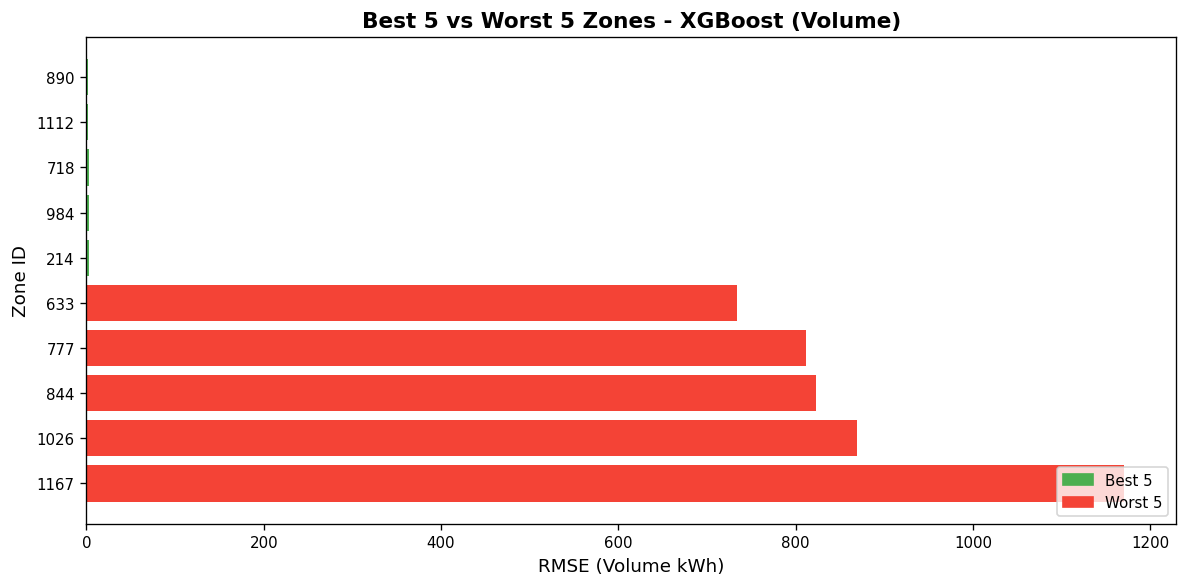

In [19]:
vol_pred_col_best = f"{best_vol_model.lower()}_vol_pred"

zone_rmse_vol = pred_df.groupby('zone_id').apply(
    lambda g: np.sqrt(((g['actual_volume'] - g[vol_pred_col_best]) ** 2).mean())
).reset_index(name='RMSE').sort_values('RMSE')

top5_vol = zone_rmse_vol.head(5)
bottom5_vol = zone_rmse_vol.tail(5)
plot_zones_vol = pd.concat([top5_vol, bottom5_vol])

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors_vol = ['#4CAF50'] * len(top5_vol) + ['#F44336'] * len(bottom5_vol)
ax.barh(plot_zones_vol['zone_id'].astype(str), plot_zones_vol['RMSE'], color=bar_colors_vol)
ax.set_xlabel("RMSE (Volume kWh)")
ax.set_ylabel("Zone ID")
ax.set_title(f"Best 5 vs Worst 5 Zones - {best_vol_model} (Volume)", fontweight='bold')
ax.invert_yaxis()

ax.legend(handles=[Patch(color='#4CAF50', label='Best 5'),
                   Patch(color='#F44336', label='Worst 5')],
          loc='lower right')

plt.tight_layout()
plt.savefig("../results/charts/chart_15_zone_rmse_volume.png", bbox_inches='tight')
plt.show()

## Chart 16 - Hourly Pattern: Actual vs Predicted (Occupancy)

Mean occupancy by hour of day - do models capture the daily rhythm?

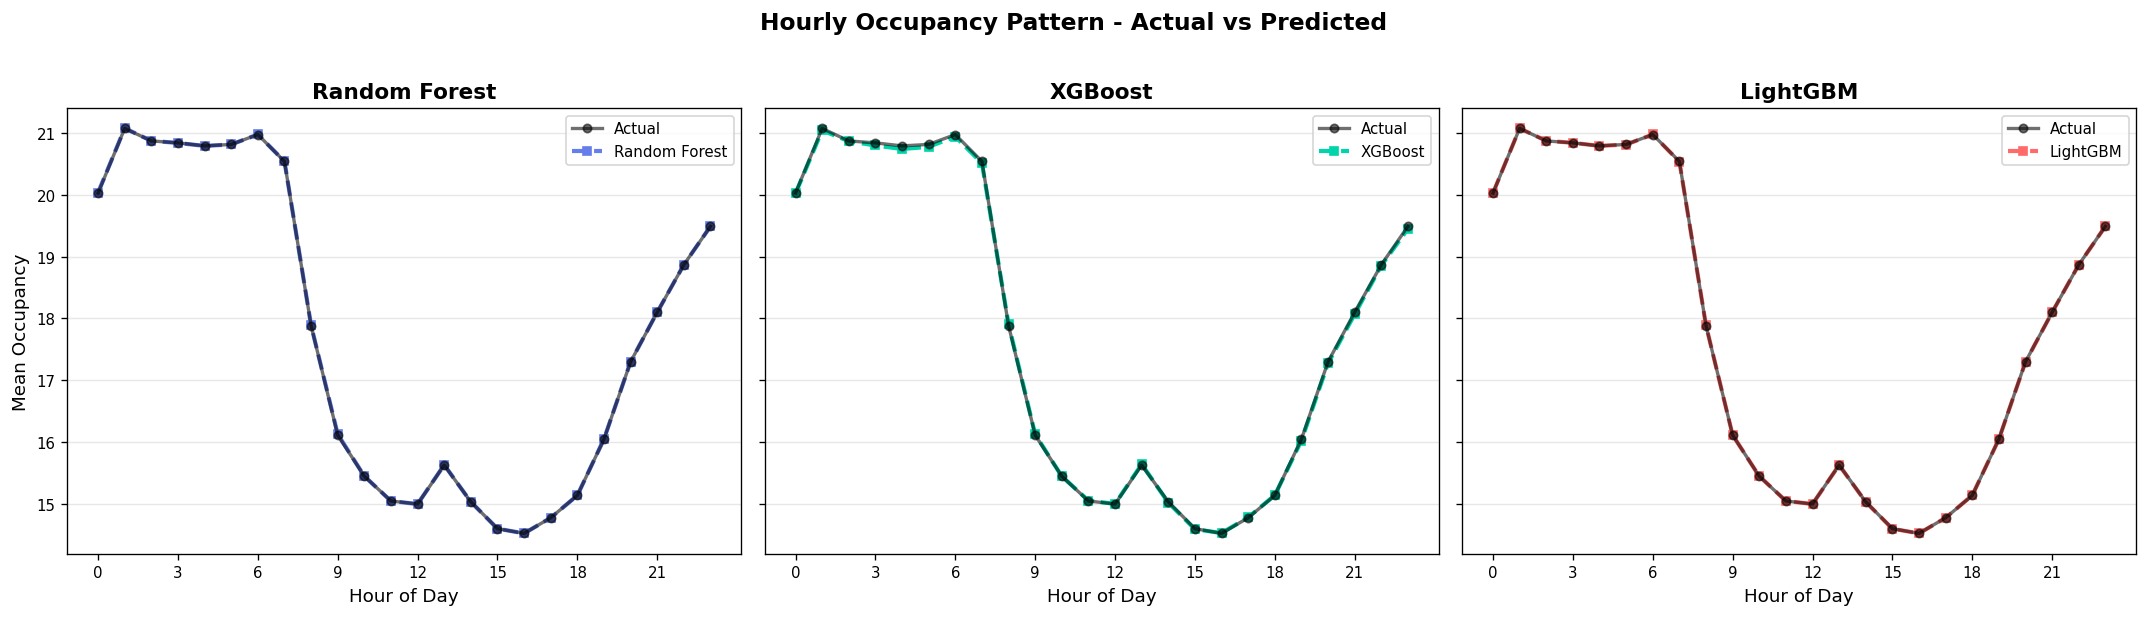

In [20]:
pred_df['hour'] = pred_df['time'].dt.hour

hourly = pred_df.groupby('hour').agg(
    actual=('actual_occupancy', 'mean'),
    rf_pred=('randomforest_occ_pred', 'mean'),
    xgb_pred=('xgboost_occ_pred', 'mean'),
    lgb_pred=('lightgbm_occ_pred', 'mean')
).reset_index()

model_info = [
    ('rf_pred', 'Random Forest', '#667eea'),
    ('xgb_pred', 'XGBoost', '#00d4aa'),
    ('lgb_pred', 'LightGBM', '#ff6b6b')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (col, name, color) in zip(axes, model_info):
    ax.plot(hourly['hour'], hourly['actual'], '-o', color="#00000090", linewidth=2, markersize=5, label='Actual', zorder=5)
    ax.plot(hourly['hour'], hourly[col], '--s', color=color, linewidth=2.5, markersize=5, label=name)
    ax.set_xlabel("Hour of Day")
    ax.set_title(name, fontweight='bold')
    ax.set_xticks(range(0, 24, 3))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel("Mean Occupancy")
fig.suptitle("Hourly Occupancy Pattern - Actual vs Predicted", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/charts/chart_16_hourly_pattern_occupancy.png", bbox_inches='tight')
plt.show()

## Chart 17 - Hourly Pattern: Actual vs Predicted (Volume)

Mean volume (kWh) by hour of day - do models capture the daily charging volume rhythm?

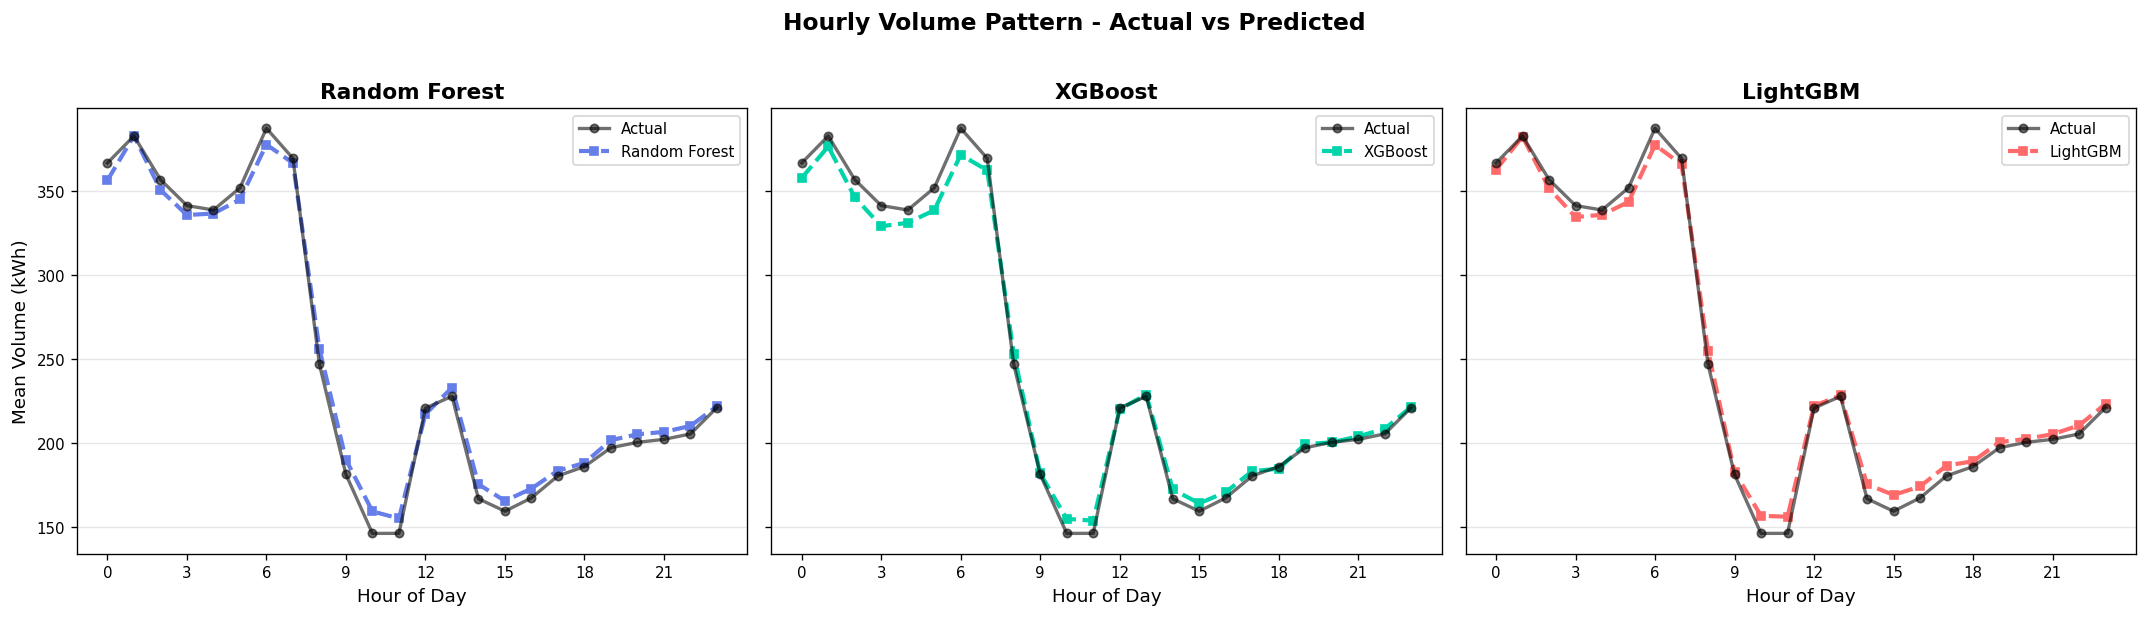

In [21]:
hourly_vol = pred_df.groupby('hour').agg(
    actual=('actual_volume', 'mean'),
    rf_pred=('randomforest_vol_pred', 'mean'),
    xgb_pred=('xgboost_vol_pred', 'mean'),
    lgb_pred=('lightgbm_vol_pred', 'mean')
).reset_index()

model_info_vol = [
    ('rf_pred', 'Random Forest', '#667eea'),
    ('xgb_pred', 'XGBoost', '#00d4aa'),
    ('lgb_pred', 'LightGBM', '#ff6b6b')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (col, name, color) in zip(axes, model_info_vol):
    ax.plot(hourly_vol['hour'], hourly_vol['actual'], '-o', color="#00000090", linewidth=2, markersize=5, label='Actual', zorder=5)
    ax.plot(hourly_vol['hour'], hourly_vol[col], '--s', color=color, linewidth=2.5, markersize=5, label=name)
    ax.set_xlabel("Hour of Day")
    ax.set_title(name, fontweight='bold')
    ax.set_xticks(range(0, 24, 3))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel("Mean Volume (kWh)")
fig.suptitle("Hourly Volume Pattern - Actual vs Predicted", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../results/charts/chart_17_hourly_pattern_volume.png", bbox_inches='tight')
plt.show()

## Chart 18 - Price Sensitivity Analysis

How does electricity price relate to occupancy and volume?

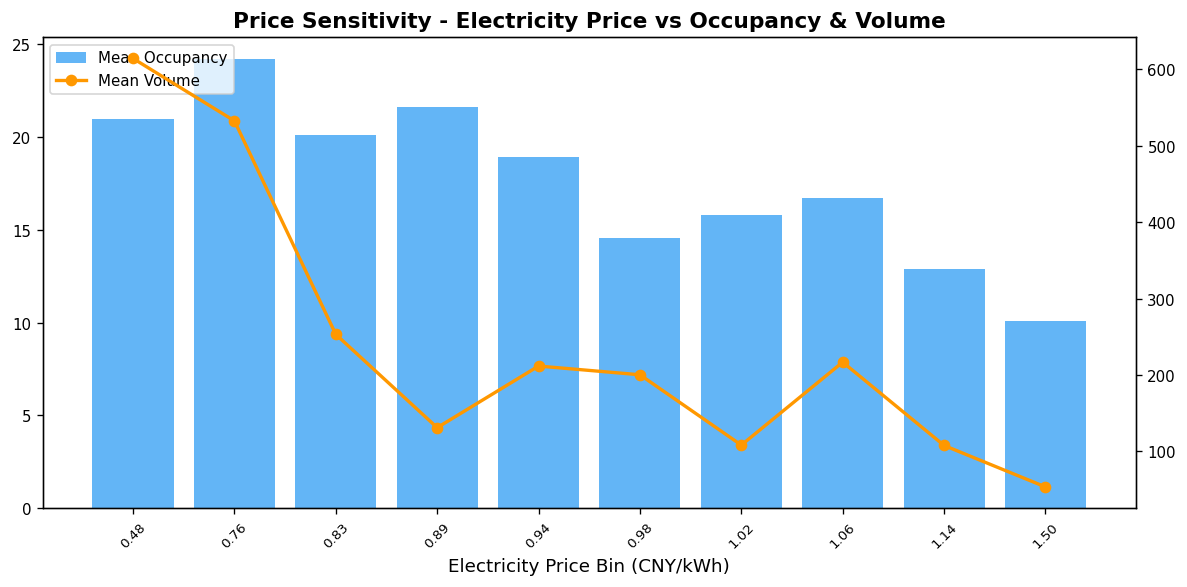

In [22]:
# Load the featured dataset to get price columns (not in predictions file)
parts = sorted(glob.glob("../data/processed/final_featured_dataset_part_*.csv"))
feat_df = pd.concat([pd.read_csv(f) for f in parts], ignore_index=True)
feat_df['time'] = pd.to_datetime(feat_df['time'])

# Filter to test period only
split_date = pd.Timestamp("2023-02-01")
test_feat = feat_df[feat_df['time'] >= split_date].copy()

# Bin electricity price into groups
test_feat['e_price_bin'] = pd.qcut(test_feat['e_price'], q=10, duplicates='drop')

price_occ = test_feat.groupby('e_price_bin', observed=True).agg(
    mean_occ=('occupancy', 'mean'),
    mean_vol=('volume', 'mean'),
    count=('occupancy', 'size')
).reset_index()

price_occ['price_mid'] = price_occ['e_price_bin'].apply(lambda x: x.mid)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(range(len(price_occ)), price_occ['mean_occ'], color='#2196F3', alpha=0.7, label='Mean Occupancy')
ax1.set_xlabel("Electricity Price Bin (CNY/kWh)")
ax1.set_xticks(range(len(price_occ)))
ax1.set_xticklabels([f"{x:.2f}" for x in price_occ['price_mid']], rotation=45, fontsize=8)

ax2 = ax1.twinx()
ax2.plot(range(len(price_occ)), price_occ['mean_vol'], 'o-', color='#FF9800', linewidth=2, label='Mean Volume')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title("Price Sensitivity - Electricity Price vs Occupancy & Volume", fontweight='bold')
plt.tight_layout()
plt.savefig("../results/charts/chart_18_price_sensitivity.png", bbox_inches='tight')
plt.show()

## Chart 19 - Geographic Demand Map (Shenzhen, Occupancy)

Interactive map showing mean **occupancy** per zone. Bubble size and color represent demand intensity.

In [23]:
# Load zone metadata
zone_info = pd.read_csv("../data/raw/zone-information.csv")
zone_info.rename(columns={"TAZID": "zone_id"}, inplace=True)

# Compute mean occupancy & volume per zone from test predictions
zone_avg = pred_df.groupby('zone_id').agg(
    mean_occ=('actual_occupancy', 'mean'),
    mean_vol=('actual_volume', 'mean'),
).reset_index()

# Merge with zone lat/lon
zone_avg = zone_avg.merge(zone_info[['zone_id', 'longitude', 'latitude', 'charge_count']], on='zone_id', how='left')

fig = px.scatter_mapbox(
    zone_avg,
    lat="latitude", lon="longitude",
    color="mean_occ", size="mean_occ", size_max=18,
    color_continuous_scale="Turbo",
    hover_data=["zone_id", "charge_count", "mean_occ", "mean_vol"],
    mapbox_style="carto-positron", zoom=10,
    title="Mean Occupancy by Zone - Shenzhen",
    height=550,
    center={"lat": zone_avg["latitude"].mean(), "lon": zone_avg["longitude"].mean()},
)
fig.show()

## Chart 20 - Geographic Demand Map (Shenzhen, Volume)

Interactive map showing mean **volume (kWh)** per zone. Bubble size and color represent charging volume intensity.

In [24]:
fig = px.scatter_mapbox(
    zone_avg,
    lat="latitude", lon="longitude",
    color="mean_vol", size="mean_vol", size_max=18,
    color_continuous_scale="Turbo",
    hover_data=["zone_id", "charge_count", "mean_occ", "mean_vol"],
    mapbox_style="carto-positron", zoom=10,
    title="Mean Volume (kWh) by Zone - Shenzhen",
    height=550,
    center={"lat": zone_avg["latitude"].mean(), "lon": zone_avg["longitude"].mean()},
)
fig.show()

## Chart 21 - Demand vs Infrastructure Capacity

Relationship between number of charging piles and occupancy per zone, colored by volume.

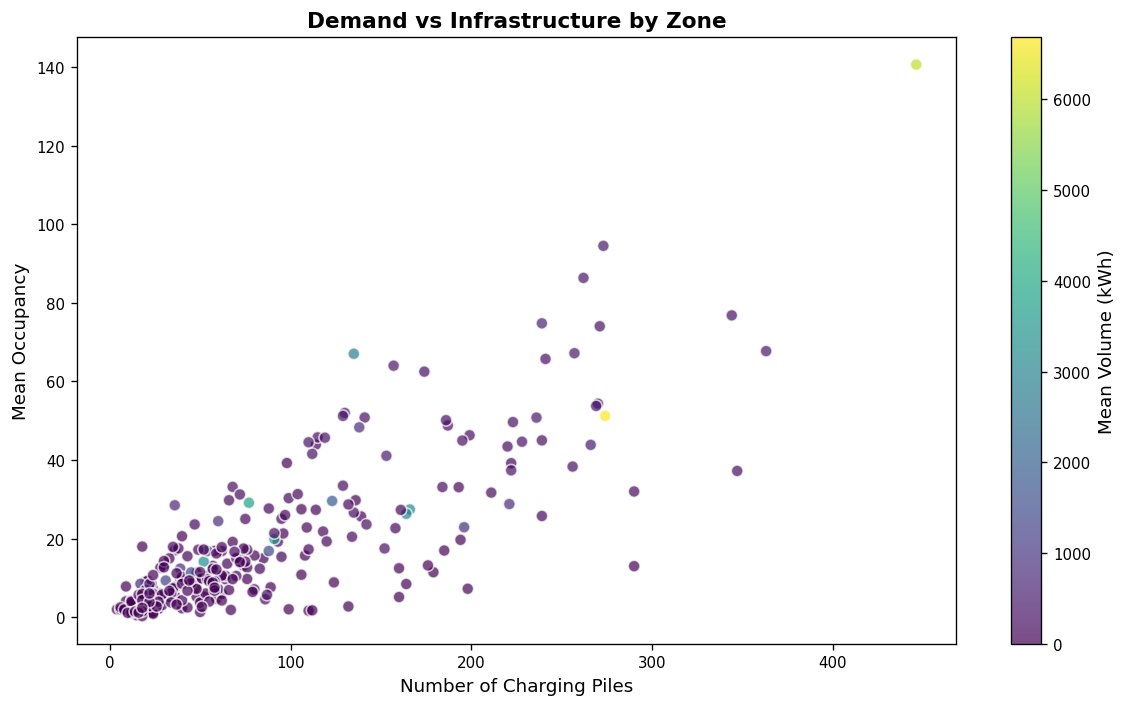

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    zone_avg["charge_count"], zone_avg["mean_occ"],
    c=zone_avg["mean_vol"], cmap="viridis",
    s=50, alpha=0.7, edgecolors="white",
)
plt.colorbar(sc, label="Mean Volume (kWh)")
ax.set_xlabel("Number of Charging Piles")
ax.set_ylabel("Mean Occupancy")
ax.set_title("Demand vs Infrastructure by Zone", fontweight="bold")
plt.tight_layout()
plt.savefig("../results/charts/chart_21_demand_vs_infrastructure.png", bbox_inches='tight')
plt.show()

## Key Findings & Analysis

### Model Performance (Charts 1–3)
- **All 3 models achieve R² > 0.99 on occupancy**, indicating near-perfect predictive ability for the primary target
- **Volume prediction** is more challenging (R² ≈ 0.95–0.96), reflecting higher variance in charging energy consumption
- LightGBM and Random Forest perform comparably on occupancy; XGBoost leads on volume (lowest RMSE)
- The combined heatmap (Chart 3) provides a quick cross-target, cross-model comparison at a glance

### Prediction Quality (Charts 4–9)
- **Time series plots** (Charts 4–5) confirm the best model closely tracks actual values for both occupancy and volume over a full week
- **Scatter plots** (Charts 6–7) show tight clustering along the identity line, especially for occupancy; volume shows slightly more spread at higher values
- **Residual distributions** (Charts 8–9) are centered around 0 with near-zero mean error, confirming unbiased predictions for both targets
- Volume residuals have wider spread than occupancy, consistent with the lower R² scores

### Feature Importance (Charts 10–13)
- **Lag features** (occ_lag_1h, occ_lag_24h, vol_lag_1h) dominate across all models — recent history is the strongest predictor
- **Rolling mean features** capture trend momentum and provide smoothed signals
- **Cyclical time encoding** (hour_sin, hour_cos) effectively captures daily charging patterns
- **Spatial features** (charge_density, total_piles) provide zone-specific context
- Feature importance rankings differ between occupancy (Charts 10, 12) and volume (Charts 11, 13), showing each target relies on different feature subsets
- Model-to-model comparison reveals tree-based models assign importance differently — ensemble diversity contributes to robustness

### Zone-Level Analysis (Charts 14–15)
- Some zones are consistently harder to predict — likely zones with irregular or sparse charging activity
- The best 5 zones achieve near-zero RMSE for occupancy; worst zones may benefit from additional spatial or contextual features
- Volume zone-level errors are larger in absolute terms but proportionally consistent

### Temporal Patterns (Charts 16–17)
- All models effectively capture the **daily occupancy and volume rhythm** across 24 hours
- Occupancy peaks during nighttime hours (vehicles parked and charging overnight)
- Volume shows distinct morning and evening peaks aligned with commuter charging behavior
- Predicted hourly profiles closely overlay actual patterns, confirming temporal feature engineering effectiveness

### Price Sensitivity (Chart 18)
- Electricity price shows a measurable relationship with both occupancy and volume
- Lower-price periods tend to correlate with higher charging volume — users are price-sensitive
- The dual-axis visualization reveals that occupancy and volume respond differently to price changes

### Spatial Distribution (Charts 19–20)
- Geographic maps reveal **uneven demand distribution** across Shenzhen's 275 zones
- High-occupancy zones cluster in central urban areas with dense commercial/residential activity
- Volume hotspots partially overlap with occupancy but also appear near highway corridors and industrial zones
- Hover data enables zone-by-zone inspection of infrastructure capacity vs actual demand

### Infrastructure vs Demand (Chart 21)
- Zones with more charging piles do not necessarily have higher occupancy — suggesting some areas are over-provisioned
- The volume color gradient reveals that high-pile zones tend to serve higher energy throughput
- This chart can guide **infrastructure planning** — identifying under-served zones for expansion